# Notebook 2: Exploratory Data Analysis (EDA)
>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Go to project root if running from notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

os.makedirs('charts', exist_ok=True)

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'axes.edgecolor':   '#444',
    'grid.color':       '#333',
    'figure.dpi':       120,
})
ACCENT = '#7c4dff'
COLORS = ['#7c4dff', '#00e5ff', '#ff6d6d', '#69f0ae', '#ffab00']

rides     = pd.read_csv('data/processed/rides_clean.csv', parse_dates=['ride_date'])
completed = rides[rides['ride_status'] == 'Completed']

print('=== DATASET SUMMARY ===')
print(f'Total rides   : {len(rides):,}')
print(f'Completed     : {len(completed):,}  ({len(completed)/len(rides):.1%})')
print(f'Cancelled     : {(rides["ride_status"]=="Cancelled").sum():,}')
print(f'Date range    : {rides["ride_date"].min().date()} to {rides["ride_date"].max().date()}')
print(f'Total revenue : INR {completed["fare_amount"].sum():,.0f}')
print(f'Avg fare      : INR {completed["fare_amount"].mean():.2f}')
print(f'Avg distance  : {completed["distance_km"].mean():.2f} km')

=== DATASET SUMMARY ===
Total rides   : 45,841
Completed     : 36,615  (79.9%)
Cancelled     : 6,497
Date range    : 2024-01-01 to 2024-12-31
Total revenue : INR 2,791,499
Avg fare      : INR 76.24
Avg distance  : 5.07 km


## Chart 1 — Hourly Demand Heatmap


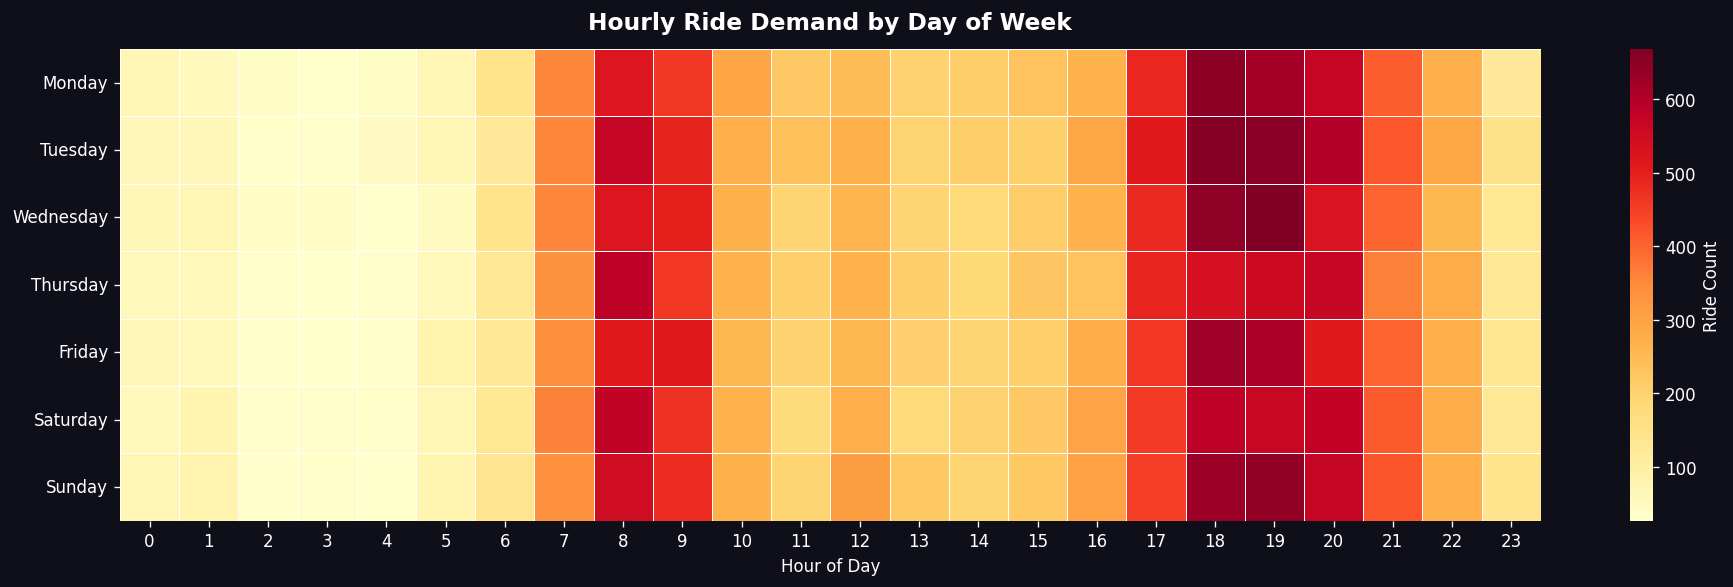

Saved: charts/01_hourly_heatmap.png


In [2]:
fig, ax = plt.subplots(figsize=(16, 5))

pivot = rides.groupby(['day_of_week', 'ride_hour']).size().unstack(fill_value=0)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Ride Count'})
ax.set_title('Hourly Ride Demand by Day of Week', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('charts/01_hourly_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: charts/01_hourly_heatmap.png')

## Chart 2 — Revenue by Pickup Zone


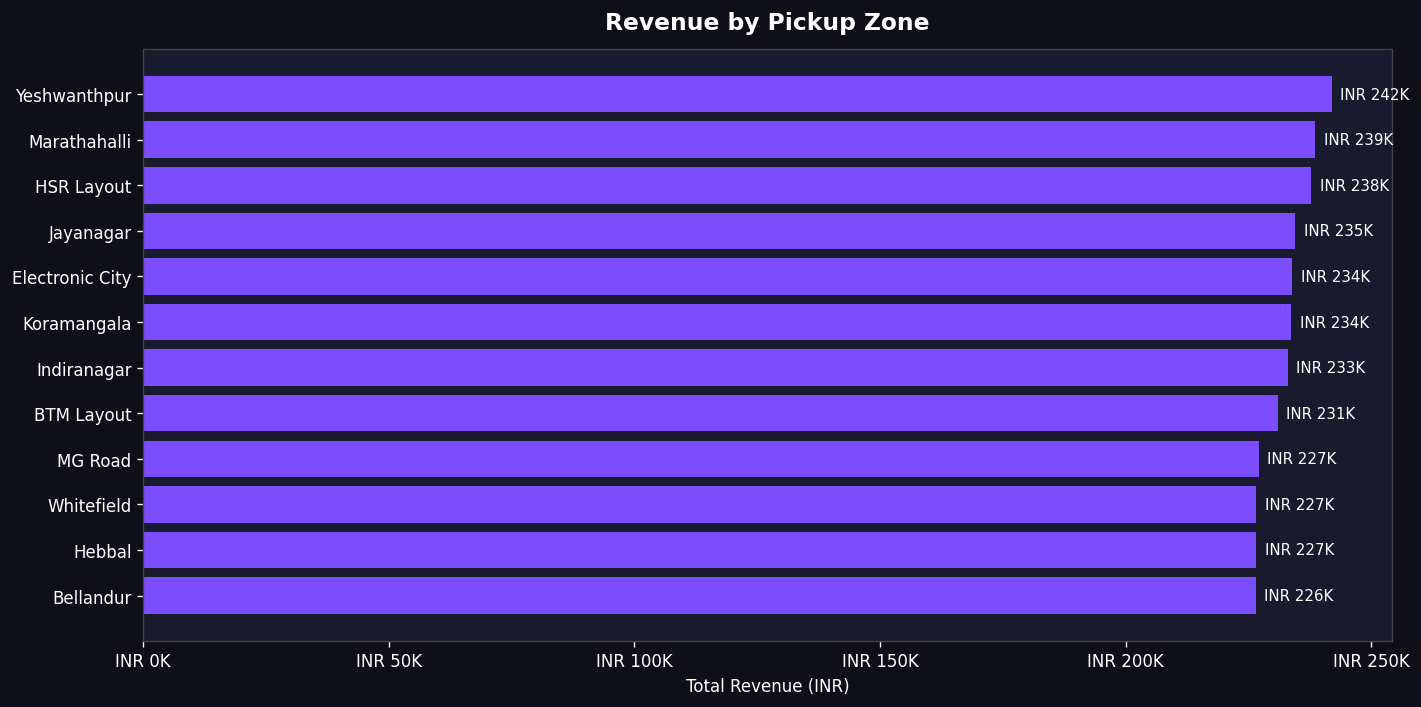

Saved: charts/02_zone_revenue.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

zone_rev = completed.groupby('pickup_zone')['fare_amount'].sum().sort_values(ascending=True)

bars = ax.barh(zone_rev.index, zone_rev.values, color=ACCENT, edgecolor='none')
ax.bar_label(bars, labels=[f'INR {v/1000:.0f}K' for v in zone_rev.values],
             padding=5, color='white', fontsize=9)
ax.set_title('Revenue by Pickup Zone', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Total Revenue (INR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/02_zone_revenue.png', bbox_inches='tight')
plt.show()
print('Saved: charts/02_zone_revenue.png')

## Chart 3 — Cancellation Rate by Hour


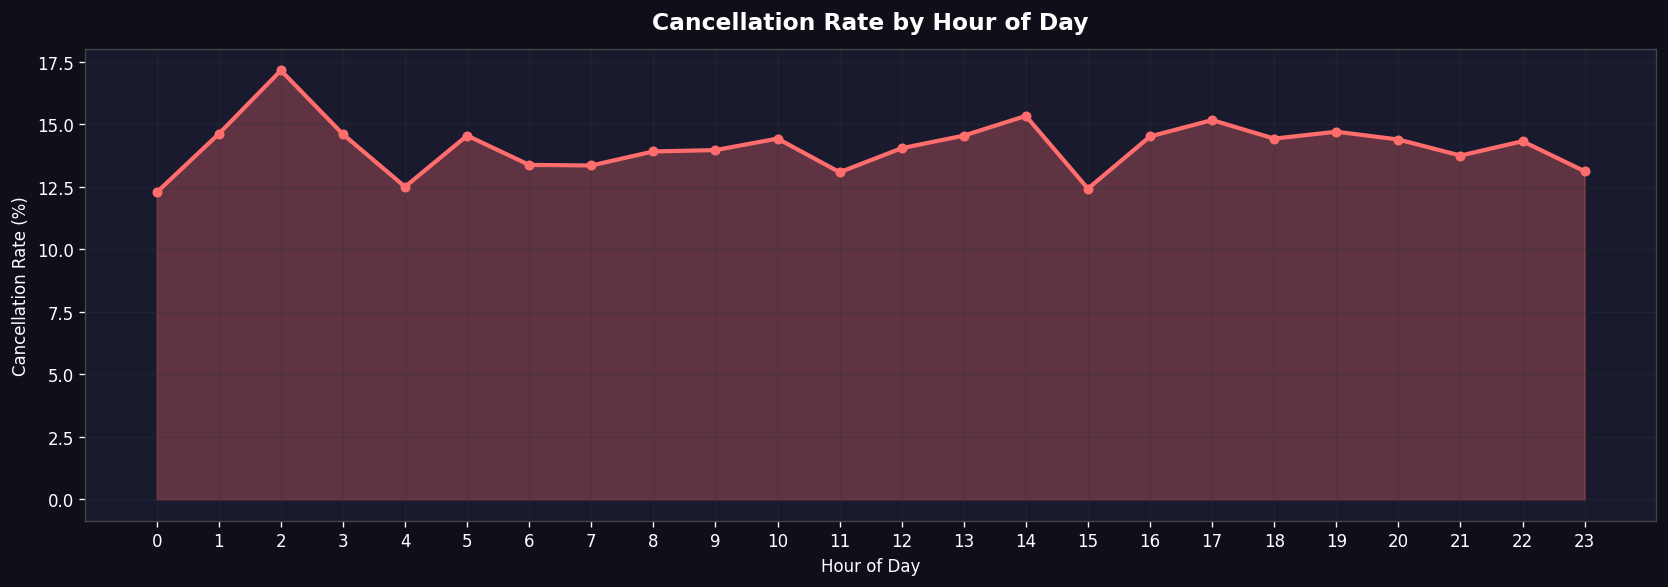

Saved: charts/03_cancellation_by_hour.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

cancel_hr = rides.groupby('ride_hour').apply(
    lambda g: (g['ride_status'] == 'Cancelled').mean() * 100
).reset_index(name='cancel_rate')

ax.fill_between(cancel_hr['ride_hour'], cancel_hr['cancel_rate'],
                alpha=0.3, color='#ff6d6d')
ax.plot(cancel_hr['ride_hour'], cancel_hr['cancel_rate'],
        color='#ff6d6d', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Cancellation Rate by Hour of Day', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/03_cancellation_by_hour.png', bbox_inches='tight')
plt.show()
print('Saved: charts/03_cancellation_by_hour.png')

## Chart 4 — Monthly Revenue Trend


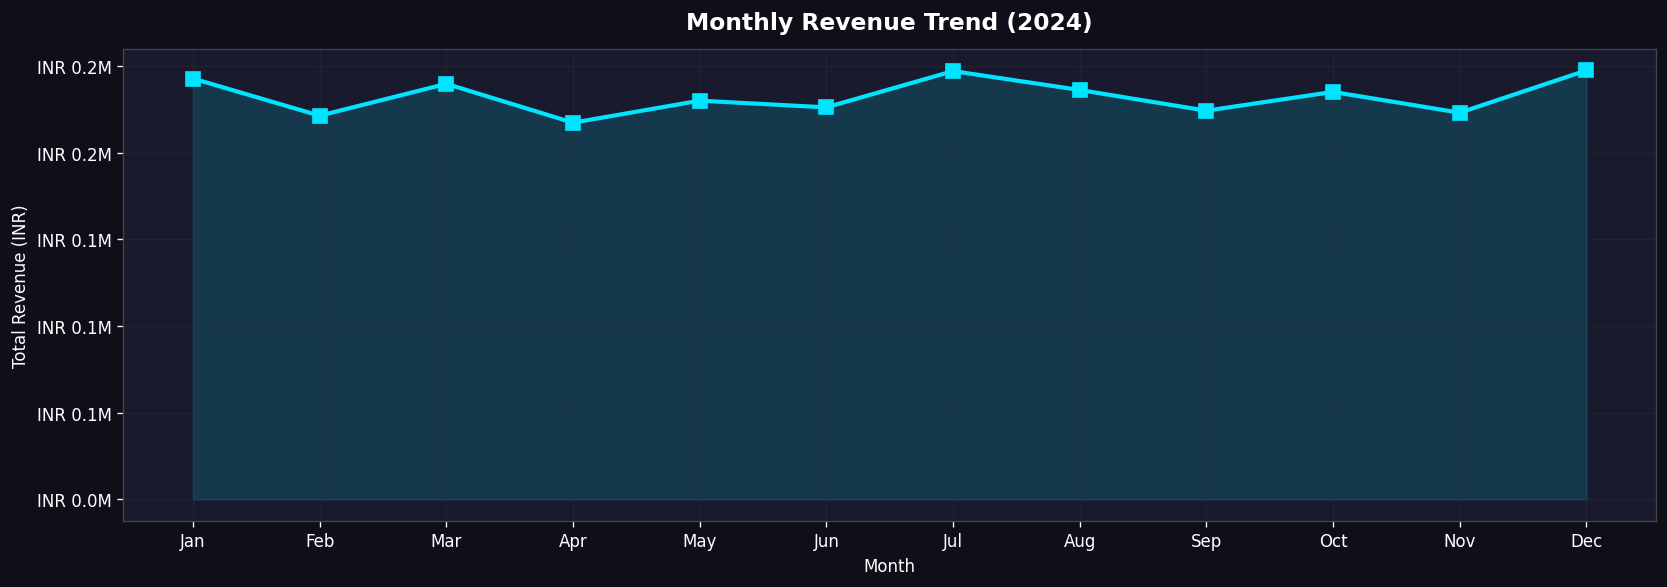

Saved: charts/04_monthly_trend.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly = completed.groupby('month')['fare_amount'].sum().reset_index()
monthly['label'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')

ax.plot(monthly['label'], monthly['fare_amount'],
        color='#00e5ff', linewidth=2.5, marker='s', markersize=8)
ax.fill_between(monthly['label'], monthly['fare_amount'],
                alpha=0.15, color='#00e5ff')
ax.set_title('Monthly Revenue Trend (2024)', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {x/1e6:.1f}M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/04_monthly_trend.png', bbox_inches='tight')
plt.show()
print('Saved: charts/04_monthly_trend.png')

## Chart 5 — Fare Distribution: Completed vs Cancelled


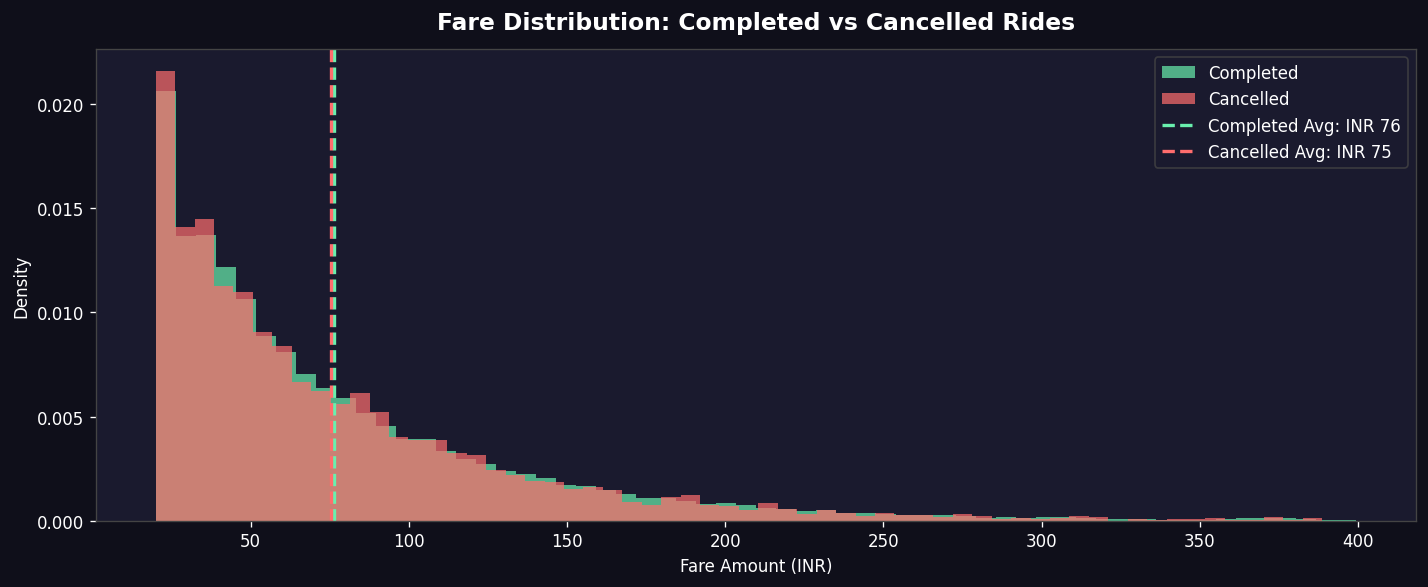

Saved: charts/05_fare_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

comp_fares   = rides[rides['ride_status'] == 'Completed']['fare_amount']
cancel_fares = rides[rides['ride_status'] == 'Cancelled']['fare_amount']

ax.hist(comp_fares,   bins=60, alpha=0.7, color='#69f0ae', label='Completed', density=True)
ax.hist(cancel_fares, bins=60, alpha=0.7, color='#ff6d6d', label='Cancelled', density=True)
ax.axvline(comp_fares.mean(),   color='#69f0ae', linestyle='--', linewidth=2,
           label=f'Completed Avg: INR {comp_fares.mean():.0f}')
ax.axvline(cancel_fares.mean(), color='#ff6d6d', linestyle='--', linewidth=2,
           label=f'Cancelled Avg: INR {cancel_fares.mean():.0f}')
ax.set_title('Fare Distribution: Completed vs Cancelled Rides', fontsize=14, pad=12, fontweight='bold')
ax.set_xlabel('Fare Amount (INR)')
ax.set_ylabel('Density')
ax.legend(facecolor='#1a1a2e', edgecolor='#444')
plt.tight_layout()
plt.savefig('charts/05_fare_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: charts/05_fare_distribution.png')

## Chart 6 — Payment Mode Breakdown


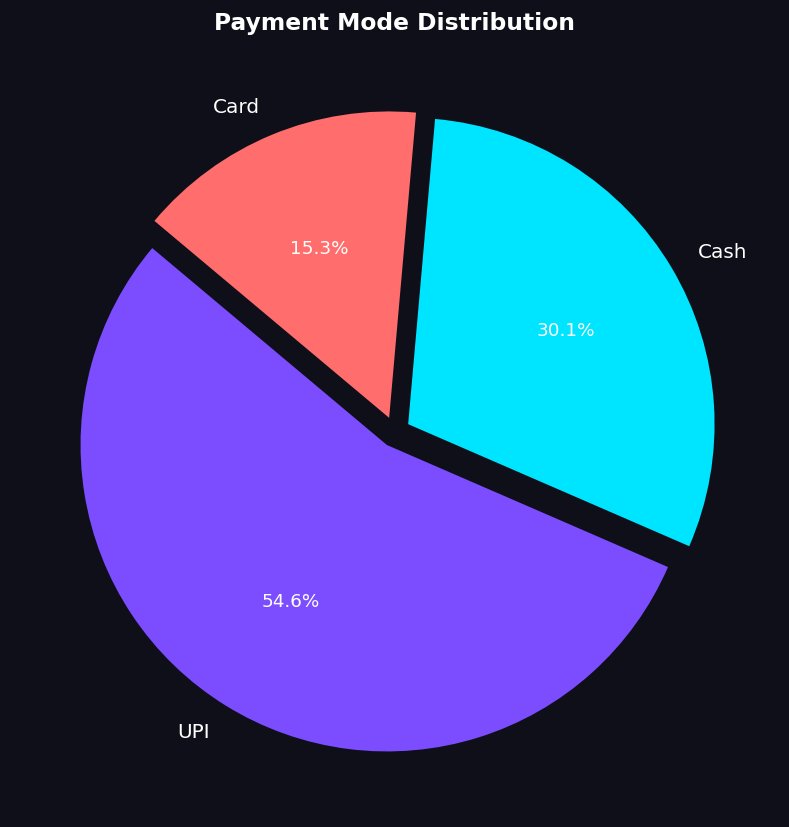

Saved: charts/06_payment_modes.png

All 6 charts saved!


In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

pay_counts = completed['payment_mode'].value_counts()

wedges, texts, autotexts = ax.pie(
    pay_counts,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    colors=COLORS[:len(pay_counts)],
    explode=[0.05] * len(pay_counts),
    startangle=140,
    textprops={'color': 'white', 'fontsize': 12},
)
for at in autotexts:
    at.set_fontsize(11)

ax.set_title('Payment Mode Distribution', fontsize=14, pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_payment_modes.png', bbox_inches='tight')
plt.show()
print('Saved: charts/06_payment_modes.png')
print('\nAll 6 charts saved!')

## Summary Stats — Time Bucket Analysis

In [8]:
bucket_order = ['Morning Rush','Midday','Afternoon','Evening Rush','Night','Late Night']

summary = (
    rides.groupby('time_bucket')
    .agg(
        total_rides   = ('ride_id',     'count'),
        avg_fare      = ('fare_amount', 'mean'),
        cancel_rate   = ('ride_status', lambda x: (x == 'Cancelled').mean() * 100),
        avg_distance  = ('distance_km', 'mean'),
    )
    .reindex(bucket_order)
    .round(2)
)

print('=== BUSINESS SUMMARY BY TIME BUCKET ===')
print(summary.to_string())

=== BUSINESS SUMMARY BY TIME BUCKET ===
              total_rides  avg_fare  cancel_rate  avg_distance
time_bucket                                                   
Morning Rush        10600     76.13        13.75          5.07
Midday               5230     76.50        13.92          5.09
Afternoon            6270     77.40        14.19          5.17
Evening Rush        15919     75.78        14.65          5.03
Night                5701     75.65        13.84          5.04
Late Night           2121     75.47        14.14          4.99
